In [33]:
import pandas as pd 
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader , Dataset
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt 


In [34]:
torch.manual_seed(42)


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pandey881062/fmnist-small-csv")

print("Path to dataset files:", path)


c:\Users\manas\anaconda3\envs\tf-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.37M/3.37M [00:03<00:00, 1.13MB/s]

Extracting files...
Path to dataset files: C:\Users\manas\.cache\kagglehub\datasets\pandey881062\fmnist-small-csv\versions\1


In [35]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


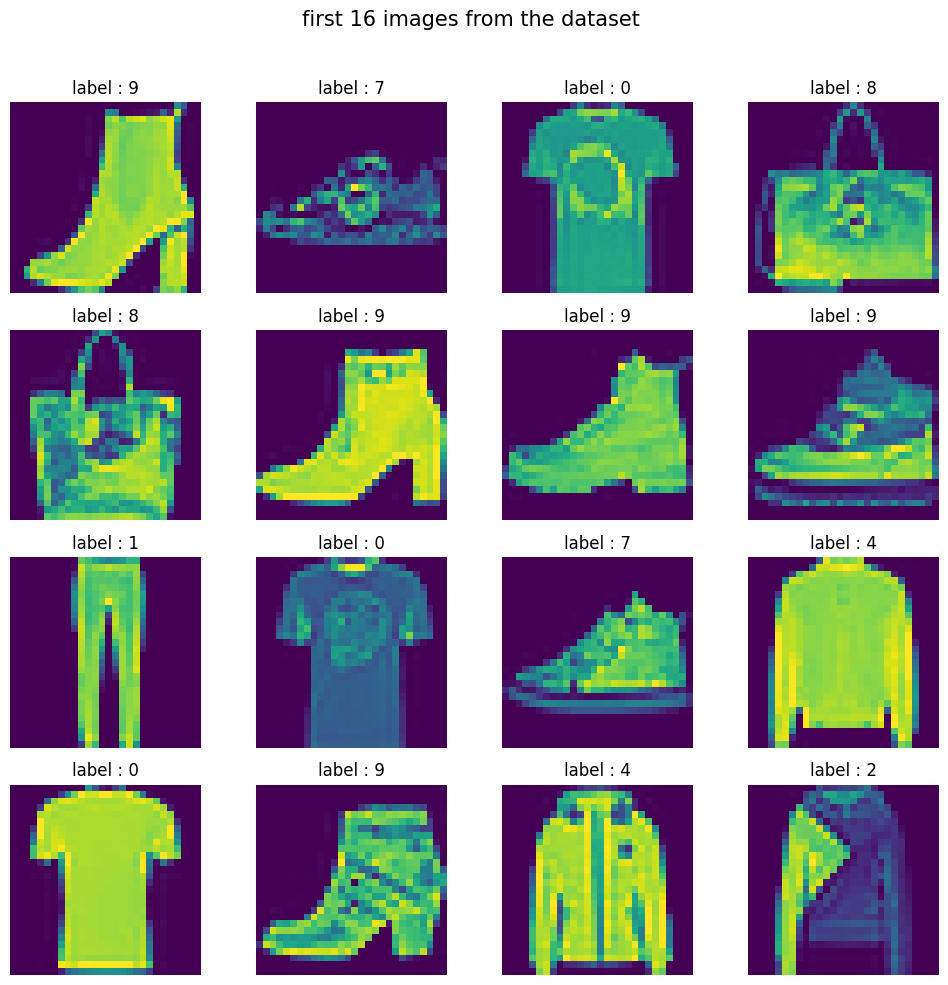

In [36]:
fig , axes = plt.subplots(4,4, figsize = (10 ,10))
fig.suptitle('first 16 images from the dataset ' , fontsize = 15)


for i , ax in enumerate(axes.flat):
    img = df.iloc[i , 1:].values.reshape(28 , 28)
    ax.imshow(img )
    ax.axis('off')
    ax.set_title(f'label : {df.iloc[i , 0]}')

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()



In [37]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [38]:
X_train , X_test , y_train , y_test = train_test_split(X ,y, test_size = 0.2 , random_state = 42)


In [39]:
X_train = X_train / 255.0
X_test = X_test / 255.0



In [40]:
class CustomDataset(Dataset):

    def __init__(self, features , labels):
        self.features = torch.tensor(features , dtype=torch.float32)
        self.labels = torch.tensor(labels , dtype = torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self , index):
        return self.features[index] , self.labels[index]




In [41]:
train_dataset = CustomDataset(X_train , y_train)
train_dataset[0]


(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [42]:
test_dataset = CustomDataset(X_test , y_test)

test_dataset[2]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [65]:
from torch.utils.data import RandomSampler
sampler = RandomSampler(train_dataset , replacement = True , num_samples = 1000)
train_loader = DataLoader(train_dataset , sampler = sampler , batch_size = 32 , num_workers=0)
test_loader = DataLoader(test_dataset , batch_size = 32 , shuffle = False , num_workers=0)

In [66]:
class MyNN(nn.Module):

    def __init__(self, num_features):

        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features , 128) , 
            nn.ReLU(),
            nn.Linear(128 , 64),
            nn.ReLU(),
            nn.Linear(64 , 10)
        )

    def forward(self , x):
        return self.model(x)

In [67]:
epochs = 25 
learning_rate = 0.01


In [68]:
model = MyNN(X_train.shape[1])


#loss functionb 
loss_function = nn.CrossEntropyLoss()

# optimizer 
optimizer = optim.Adam(model.parameters() , lr = learning_rate)




In [69]:
len(train_loader)

32

In [70]:
for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features , batch_labels in train_loader:

        outputs = model(batch_features)

        loss = loss_function(outputs , batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch {epoch + 1} loss: {avg_loss}")

Epoch 1 loss: 1.2493667341768742
Epoch 2 loss: 0.8567001242190599
Epoch 3 loss: 0.768412291072309
Epoch 4 loss: 0.6826442060992122
Epoch 5 loss: 0.5980386286973953
Epoch 6 loss: 0.5594792757183313
Epoch 7 loss: 0.6643487769179046
Epoch 8 loss: 0.5882331086322665
Epoch 9 loss: 0.5782421296462417
Epoch 10 loss: 0.536952274851501
Epoch 11 loss: 0.509692158550024
Epoch 12 loss: 0.46462936233729124
Epoch 13 loss: 0.47724032402038574
Epoch 14 loss: 0.5010941945947707
Epoch 15 loss: 0.5155050153844059
Epoch 16 loss: 0.5605165213346481
Epoch 17 loss: 0.4386196597479284
Epoch 18 loss: 0.4782563312910497
Epoch 19 loss: 0.40902935923077166
Epoch 20 loss: 0.47304976265877485
Epoch 21 loss: 0.43474375270307064
Epoch 22 loss: 0.46738496934995055
Epoch 23 loss: 0.40890148747712374
Epoch 24 loss: 0.43886749912053347
Epoch 25 loss: 0.4364148313179612


In [71]:
model.eval()


MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [73]:
len(test_loader)

38

In [76]:
# let's seethe evaluation of the code 
total = 0
correct = 0 
with torch.no_grad():

    for batch_features , batch_labels in test_loader:
        # forward pass 
        outputs = model(batch_features)
        # get the predicted class
        predicted = torch.max(outputs , dim = 1)[1]
        # count the number of correct predictions
        total = total + batch_labels.shape[0]
        # count the number of correct predictions
        correct = correct + (predicted == batch_labels).sum().item()

    print("The accuracy of the model is",(correct / total) * 100 , "%")



The accuracy of the model is 77.25 %


Epoch 1/25 | loss: 1.3307 | val_loss: 1.0238 | acc: 0.4870 | val_acc: 0.6075
Epoch 2/25 | loss: 0.8672 | val_loss: 0.7693 | acc: 0.6730 | val_acc: 0.7250
Epoch 3/25 | loss: 0.8402 | val_loss: 0.7730 | acc: 0.7000 | val_acc: 0.6983
Epoch 4/25 | loss: 0.6193 | val_loss: 0.7047 | acc: 0.7730 | val_acc: 0.7175
Epoch 5/25 | loss: 0.5945 | val_loss: 0.7069 | acc: 0.7620 | val_acc: 0.7150
Epoch 6/25 | loss: 0.6028 | val_loss: 0.5789 | acc: 0.7760 | val_acc: 0.7883
Epoch 7/25 | loss: 0.5507 | val_loss: 0.5573 | acc: 0.7890 | val_acc: 0.8042
Epoch 8/25 | loss: 0.5397 | val_loss: 0.6913 | acc: 0.7840 | val_acc: 0.7333
Epoch 9/25 | loss: 0.6372 | val_loss: 0.6328 | acc: 0.7660 | val_acc: 0.7783
Epoch 10/25 | loss: 0.5513 | val_loss: 0.6316 | acc: 0.8010 | val_acc: 0.7783
Epoch 11/25 | loss: 0.5405 | val_loss: 0.6666 | acc: 0.8070 | val_acc: 0.7717
Epoch 12/25 | loss: 0.4750 | val_loss: 0.6180 | acc: 0.8130 | val_acc: 0.7967
Epoch 13/25 | loss: 0.4676 | val_loss: 0.8394 | acc: 0.8170 | val_acc: 0.

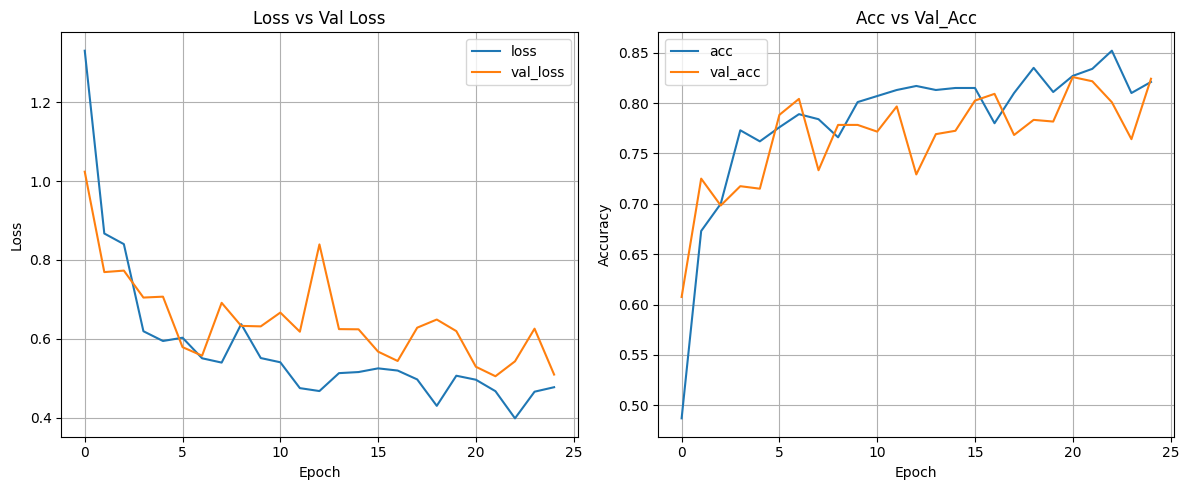

In [79]:
# Reinitialize model for a fresh training history
model = MyNN(X_train.shape[1])
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    # ----- Train -----
    model.train()
    running_loss, running_correct, running_total = 0.0, 0, 0

    for batch_features, batch_labels in train_loader:
        outputs = model(batch_features)
        loss = loss_function(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        running_correct += (preds == batch_labels).sum().item()
        running_total += batch_labels.size(0)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = running_correct / running_total

    # ----- Validation -----
    model.eval()
    val_running_loss, val_running_correct, val_running_total = 0.0, 0, 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            outputs = model(batch_features)
            loss = loss_function(outputs, batch_labels)

            val_running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_running_correct += (preds == batch_labels).sum().item()
            val_running_total += batch_labels.size(0)

    epoch_val_loss = val_running_loss / len(test_loader)
    epoch_val_acc = val_running_correct / val_running_total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"loss: {epoch_train_loss:.4f} | val_loss: {epoch_val_loss:.4f} | "
        f"acc: {epoch_train_acc:.4f} | val_acc: {epoch_val_acc:.4f}"
    )

# ----- Plot curves -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="loss")
plt.plot(val_losses, label="val_loss")
plt.title("Loss vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(train_accs, label="acc")
plt.plot(val_accs, label="val_acc")
plt.title("Acc vs Val_Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()

plt.show()